In [1]:
import os
import json
import glob
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

In [2]:
coco_train_path = "/kaggle/input/coco-2017-dataset/coco2017/train2017" 
coco_val_path   = "/kaggle/input/coco-2017-dataset/coco2017/val2017"
base_input = "/kaggle/input"

In [3]:
def find_graph_folders(root_dir):
    graph_paths = []
    for root, dirs, files in os.walk(root_dir):
        if 'graph' in dirs:
            full_path = os.path.join(root, 'graph')
            graph_paths.append(full_path)
    return graph_paths

In [4]:
dataset_roots = {
    "splicing":   os.path.join(base_input, "defactosplicing"), # Adjusted based on your debug output path
    "copymove":   os.path.join(base_input, "defactocopymove"),
    "inpainting": os.path.join(base_input, "defactoinpainting"),
    "face":       os.path.join(base_input, "defactoface")
}

**Data Mapping**

In [5]:
dataset_configs = {}

for ds_name, root_path in dataset_roots.items():
    if os.path.exists(root_path):
        found_graphs = find_graph_folders(root_path)
        if found_graphs:
            dataset_configs[ds_name] = found_graphs
            print(f"[{ds_name.upper()}] Found {len(found_graphs)} graph directories.")
        else:
            print(f"[{ds_name.upper()}] WARNING: No 'graph' folders found in {root_path}")
    else:
        print(f"[{ds_name.upper()}] WARNING: Root path not found: {root_path}")

[SPLICING] Found 7 graph directories.
[COPYMOVE] Found 1 graph directories.
[INPAINTING] Found 1 graph directories.
[FACE] Found 2 graph directories.


In [6]:
print("\n--- Step 2: Mapping Real vs Fake ---")

def get_coco_path(image_id):
    fname = str(image_id).zfill(12) + ".jpg"
    t_path = os.path.join(coco_train_path, fname)
    v_path = os.path.join(coco_val_path, fname)
    if os.path.exists(t_path): return t_path
    if os.path.exists(v_path): return v_path
    return None

final_mapping = {}

for ds_name, graph_folders in dataset_configs.items():
    print(f"Processing {ds_name}...")
    valid_pairs = []
    
    for g_folder in graph_folders:
        # Determine 'img' folder path
        parent_annotations = os.path.dirname(g_folder)
        base_dir_name = os.path.basename(parent_annotations)
        target_img_dir_name = base_dir_name.replace("annotations", "img")
        grandparent = os.path.dirname(parent_annotations)
        
        candidate_1 = os.path.join(grandparent, target_img_dir_name, "img")
        candidate_2 = os.path.join(grandparent, target_img_dir_name)
        img_folder = candidate_1 if os.path.exists(candidate_1) else candidate_2
        
        # Adjust for Face specific naming
        if "morphing" in base_dir_name: img_folder = os.path.join(grandparent, "morphing_img", "img")
        elif "swapping" in base_dir_name: img_folder = os.path.join(grandparent, "swapping_img", "img")

        json_files = [f for f in os.listdir(g_folder) if f.endswith('.json')]
        
        for j_file in json_files:
            try:
                # --- 1. FIND FAKE IMAGE ---
                fake_fname = j_file.replace(".json", ".tif")
                fake_path = os.path.join(img_folder, fake_fname)
                if not os.path.exists(fake_path):
                     fake_path = os.path.join(img_folder, j_file.replace(".json", ""))
                
                if not os.path.exists(fake_path): continue

                # --- 2. FIND REAL IMAGE ---
                real_path = None
                
                if ds_name == "face":
                    # FACE LOGIC: Filename is usually "144.jpg_IN_94.jpg.json"
                    # The first ID (144.jpg) is usually the Source/Reference
                    ref_root = os.path.join(base_input, "defactoface", "reference")
                    
                    # Extract the first part of the filename
                    # e.g. "144.jpg_IN_94.jpg.json" -> "144"
                    # e.g. "001_002.json" -> "001"
                    
                    try:
                        clean_name = j_file.split('_')[0] # Grab "144.jpg" or "001"
                        clean_name = clean_name.replace(".jpg", "") # "144"
                        
                        # Look for 144.jpg in reference
                        candidate_ref = os.path.join(ref_root, clean_name + ".jpg")
                        
                        # Recursive search if not in root reference folder
                        if os.path.exists(candidate_ref):
                            real_path = candidate_ref
                        else:
                            # Quick recursive check (Face dataset references are sometimes nested)
                            # We limit depth to avoid slow performance
                            for r, d, f in os.walk(ref_root):
                                if (clean_name + ".jpg") in f:
                                    real_path = os.path.join(r, clean_name + ".jpg")
                                    break
                    except:
                        pass
                        
                else:
                    # COCO DATASET LOGIC (Splicing, CopyMove, Inpainting)
                    # Use Filename Pattern: "ID_COCOID.json" -> Grab last part
                    # e.g. "612_000000413248.json" -> "000000413248"
                    
                    try:
                        # Split by underscore, take the last part, remove extension
                        coco_part = j_file.replace(".json", "").split("_")[-1]
                        
                        if coco_part.isdigit():
                            target_id = int(coco_part)
                            real_path = get_coco_path(target_id)
                    except:
                        pass
                
                # --- 3. SAVE PAIR ---
                if real_path and os.path.exists(real_path):
                    valid_pairs.append((fake_path, real_path))

            except Exception as e:
                continue

    final_mapping[ds_name] = valid_pairs
    print(f"  -> Mapped {len(valid_pairs)} pairs for {ds_name}")


--- Step 2: Mapping Real vs Fake ---
Processing splicing...
  -> Mapped 106392 pairs for splicing
Processing copymove...
  -> Mapped 18194 pairs for copymove
Processing inpainting...
  -> Mapped 25001 pairs for inpainting
Processing face...
  -> Mapped 79600 pairs for face


In [7]:
print("\n" + "="*30)
print("FINAL MAPPING SUMMARY")
print("="*30)

total_pairs = 0
for ds, pairs in final_mapping.items():
    count = len(pairs)
    total_pairs += count
    print(f"{ds.ljust(15)}: {count} pairs mapped")

print("-" * 30)
print(f"TOTAL IMAGES   : {total_pairs}")
print("="*30 + "\n")


FINAL MAPPING SUMMARY
splicing       : 106392 pairs mapped
copymove       : 18194 pairs mapped
inpainting     : 25001 pairs mapped
face           : 79600 pairs mapped
------------------------------
TOTAL IMAGES   : 229187



Displaying Examples (Real vs Fake)...


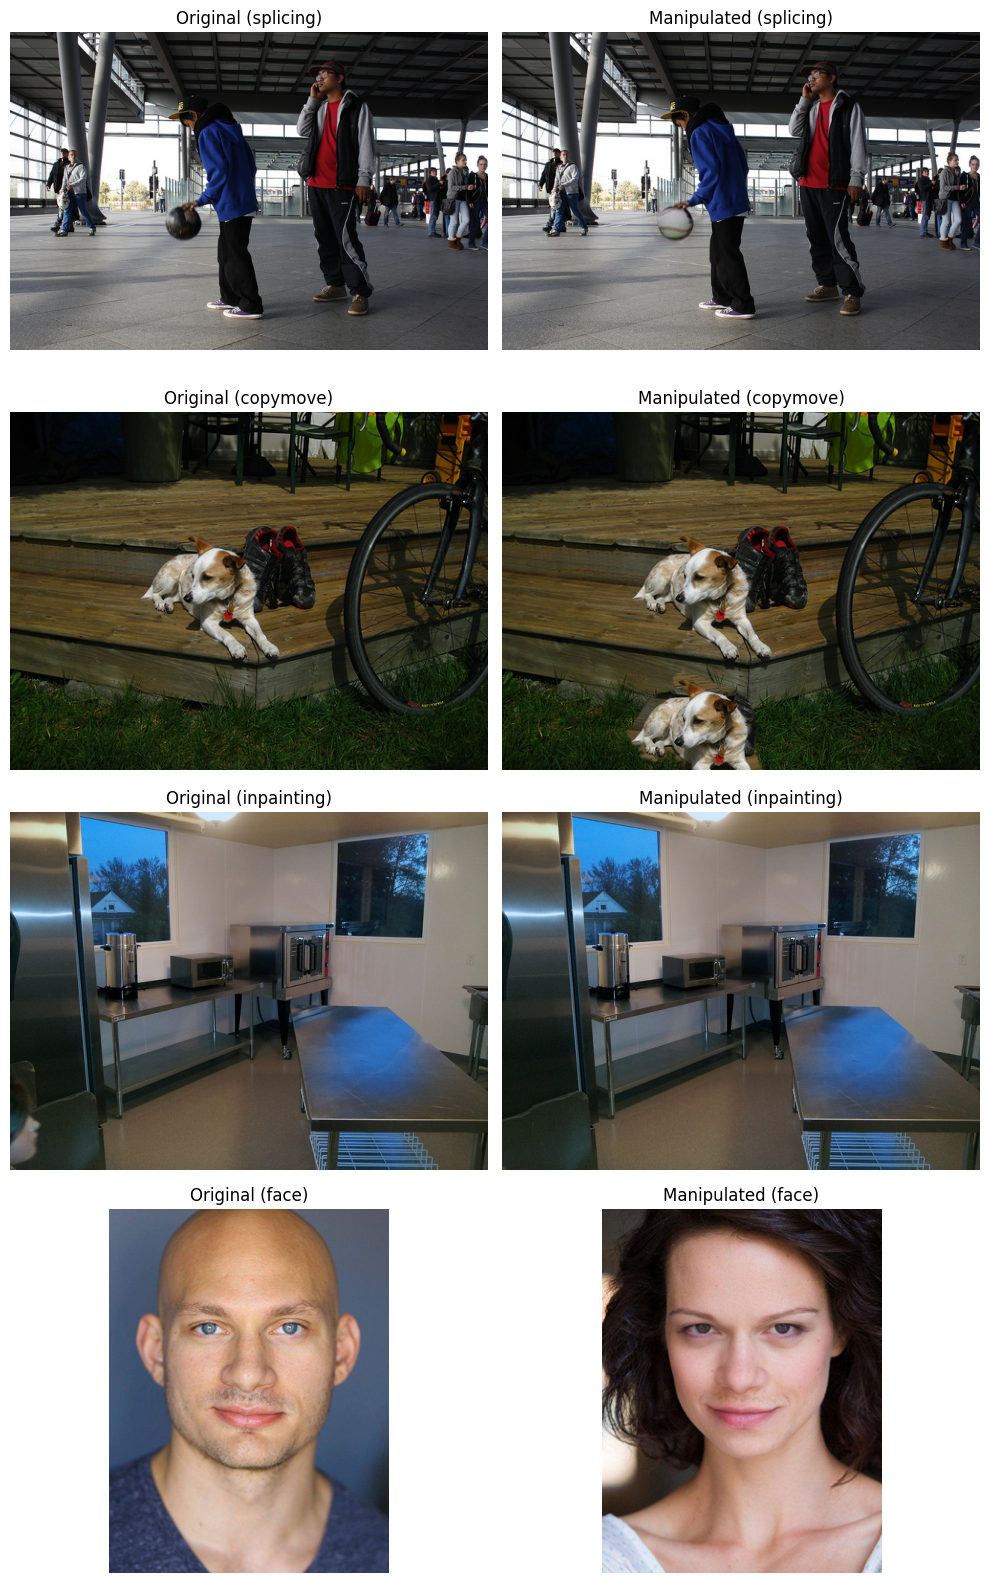

In [8]:
print("Displaying Examples (Real vs Fake)...")

# Calculate rows needed
active_datasets = [d for d in final_mapping if len(final_mapping[d]) > 0]
if len(active_datasets) > 0:
    fig, axes = plt.subplots(len(active_datasets), 2, figsize=(10, 4 * len(active_datasets)))
    if len(active_datasets) == 1: axes = [axes] # Handle single row case

    for idx, ds in enumerate(active_datasets):
        # Get a random pair
        fake_p, real_p = random.choice(final_mapping[ds])
        
        # Load just these two images
        real_img = mpimg.imread(real_p)
        fake_img = mpimg.imread(fake_p)
        
        # Plot Real
        ax_real = axes[idx][0] if len(active_datasets) > 1 else axes[0]
        ax_real.imshow(real_img)
        ax_real.set_title(f"Original ({ds})")
        ax_real.axis('off')
        
        # Plot Fake
        ax_fake = axes[idx][1] if len(active_datasets) > 1 else axes[1]
        ax_fake.imshow(fake_img)
        ax_fake.set_title(f"Manipulated ({ds})")
        ax_fake.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No valid pairs found. Please check your COCO dataset paths in the configuration.")

**Data Splitting**

In [9]:
train_ratio = 0.70
val_ratio   = 0.15
test_ratio  = 0.15

# We will store the final splits here
train_data = {}
val_data   = {}
test_data  = {}

# Global counters
total_train = 0
total_val = 0
total_test = 0

In [10]:
print("--- STARTING LEAK-FREE SPLIT (GLOBAL STRATEGY) ---\n")

# --- STEP 1: GLOBAL GROUPING ---
# We need to know EVERY variation of a Real Image across ALL datasets first.
# Structure: { 'real_path_A': [ ('splicing', fake_A1), ('copymove', fake_A2) ], ... }
global_scene_map = {}

for ds_name, pairs in final_mapping.items():
    for fake_p, real_p in pairs:
        if real_p not in global_scene_map:
            global_scene_map[real_p] = []
        # Store the dataset name with the fake path so we know where it came from
        global_scene_map[real_p].append( (ds_name, fake_p) )

# --- STEP 2: SPLIT THE UNIQUE SCENES ---
unique_scenes = list(global_scene_map.keys())
random.shuffle(unique_scenes)

num_scenes = len(unique_scenes)
num_train = int(num_scenes * train_ratio)
num_val   = int(num_scenes * val_ratio)

train_scenes = set(unique_scenes[:num_train])
val_scenes   = set(unique_scenes[num_train : num_train + num_val])
test_scenes  = set(unique_scenes[num_train + num_val:])

print(f"Total Unique Scenes (Backgrounds): {num_scenes}")
print(f"Unique Scenes in Train: {len(train_scenes)}")
print(f"Unique Scenes in Val:   {len(val_scenes)}")
print(f"Unique Scenes in Test:  {len(test_scenes)}")

# --- STEP 3: RE-ASSEMBLE DATASETS ---
# Now we put them back into the dictionary format expected by the Training Loop
# train_data = {'splicing': [(fake, real), ...], 'copymove': ...}

# Initialize empty lists for all datasets found
all_ds_names = final_mapping.keys()
for ds in all_ds_names:
    train_data[ds] = []
    val_data[ds] = []
    test_data[ds] = []

# Distribute the data
for real_p, variations in global_scene_map.items():
    # Determine which set this SCENE belongs to
    if real_p in train_scenes:
        target_dict = train_data
        total_train += len(variations)
    elif real_p in val_scenes:
        target_dict = val_data
        total_val += len(variations)
    else:
        target_dict = test_data
        total_test += len(variations)
        
    # Add all variations (splicing, copymove, etc) to that specific set
    for ds_name, fake_p in variations:
        target_dict[ds_name].append( (fake_p, real_p) )

--- STARTING LEAK-FREE SPLIT (GLOBAL STRATEGY) ---

Total Unique Scenes (Backgrounds): 39195
Unique Scenes in Train: 27436
Unique Scenes in Val:   5879
Unique Scenes in Test:  5880


In [11]:
print("\n" + "="*40)
print("FINAL DATASET SPLIT SUMMARY")
print("="*40)
print(f"TOTAL TRAIN IMAGES : {total_train}")
print(f"TOTAL VAL IMAGES   : {total_val}")
print(f"TOTAL TEST IMAGES  : {total_test}")
print(f"GRAND TOTAL        : {total_train + total_val + total_test}")
print("="*40)


FINAL DATASET SPLIT SUMMARY
TOTAL TRAIN IMAGES : 161140
TOTAL VAL IMAGES   : 33647
TOTAL TEST IMAGES  : 34400
GRAND TOTAL        : 229187


In [12]:
print("\nVerifying Data Leakage Integrity...")
leak_found = False

if total_train > 0 and total_test > 0:
    # Get all real paths in Train
    train_real_paths = set()
    for ds in train_data:
        for fake, real in train_data[ds]:
            train_real_paths.add(real)
            
    # Check against Test
    for ds in test_data:
        for fake, real in test_data[ds]:
            if real in train_real_paths:
                leak_found = True
                print(f"CRITICAL WARNING: Leak found! {real} is in both Train and Test.")
                break
        if leak_found: break

if not leak_found:
    print("SUCCESS: No data leakage detected. Scenes are perfectly separated.")
else:
    print("FAILED: Data leakage detected.")


Verifying Data Leakage Integrity...
SUCCESS: No data leakage detected. Scenes are perfectly separated.


**Model Creation and Training**

In [13]:
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import os
import torch.nn.functional as F

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [15]:
CONFIG = {
    'model_name': 'efficientnet_b4',
    'img_size': 380,
    'batch_size': 8,
    'epochs': 8,  # CHANGED: Train until epoch 8
    'lr': 1e-4,
    'num_workers': 2,
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    'best_model_path': 'best_forensic_model.pth',
    'checkpoint_path': 'training_checkpoint.pth',
    'resume_training': True,  # CHANGED: Set to True to resume
    'resume_from': '/kaggle/input/checkpoint/training_checkpoint.pth',  # NEW: Path to your checkpoint
    'start_epoch': 0  # Will be updated when resuming
}
print(f"Running on device: {CONFIG['device']}")

Running on device: cuda


In [16]:
class SRMConv2d(nn.Module):
    """
    Spatial Rich Model (SRM) Filter Layer.
    This layer extracts noise features (edges/residuals) and suppresses content.
    """
    def __init__(self, in_channels=3):
        super(SRMConv2d, self).__init__()
        
        q = [4.0, 12.0, 2.0]
        filter1 = [[0, 0, 0, 0, 0],
                   [0, -1, 2, -1, 0],
                   [0, 2, -4, 2, 0],
                   [0, -1, 2, -1, 0],
                   [0, 0, 0, 0, 0]]
        filter2 = [[-1, 2, -2, 2, -1],
                   [2, -6, 8, -6, 2],
                   [-2, 8, -12, 8, -2],
                   [2, -6, 8, -6, 2],
                   [-1, 2, -2, 2, -1]]
        filter3 = [[0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0],
                   [0, 1, -2, 1, 0],
                   [0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0]]
        
        filter1 = np.array(filter1, dtype=float) / q[0]
        filter2 = np.array(filter2, dtype=float) / q[1]
        filter3 = np.array(filter3, dtype=float) / q[2]
        
        filters = np.float32([filter1, filter2, filter3])
        self.weight = nn.Parameter(torch.from_numpy(filters).unsqueeze(1).repeat(1, 3, 1, 1), requires_grad=False)
        
    def forward(self, x):
        return F.conv2d(x, self.weight, padding=2)

In [17]:
class ForensicEfficientNet(nn.Module):
    def __init__(self, model_name='efficientnet_b4', pretrained=True):
        super(ForensicEfficientNet, self).__init__()
        
        self.srm_layer = SRMConv2d()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=1)
        
        in_features = self.backbone.get_classifier().in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1)
        )
        
    def forward(self, x):
        noise_features = self.srm_layer(x)
        logits = self.backbone(noise_features)
        return logits

In [18]:
def save_checkpoint(epoch, model, optimizer, scheduler, best_val_acc, filepath):
    """
    Save complete training state
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'config': CONFIG
    }
    torch.save(checkpoint, filepath)
    print(f"✓ Checkpoint saved at epoch {epoch+1} to {filepath}")

def load_checkpoint(filepath, model, optimizer, scheduler):
    """
    Load training state and resume
    """
    if not os.path.exists(filepath):
        print(f"❌ No checkpoint found at {filepath}. Starting from scratch.")
        return 0, 0.0
    
    print(f"\n{'='*50}")
    print(f"LOADING CHECKPOINT FROM: {filepath}")
    print(f"{'='*50}")
    
    checkpoint = torch.load(filepath, map_location=CONFIG['device'])
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    
    print(f"✓ Model state loaded")
    print(f"✓ Optimizer state loaded")
    print(f"✓ Scheduler state loaded")
    print(f"✓ Previous best validation accuracy: {best_val_acc:.2f}%")
    print(f"✓ Resuming from epoch {start_epoch}")
    print(f"{'='*50}\n")
    
    return start_epoch, best_val_acc

In [19]:
# Initialize Model
model = ForensicEfficientNet(CONFIG['model_name'])
model.to(CONFIG['device'])

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\n" + "="*40)
print(f"MODEL ARCHITECTURE: {CONFIG['model_name']} + SRM Filter")
print("="*40)
print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print("="*40 + "\n")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]


MODEL ARCHITECTURE: efficientnet_b4 + SRM Filter
Total Parameters:     18,008,106
Trainable Parameters: 18,007,881



In [20]:
# Define Transforms
train_transform = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
    ToTensorV2()
])
val_transform = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
    ToTensorV2()
])

In [21]:
class ForensicDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform
        
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        
        image = cv2.imread(img_path)
        if image is None:
            image = np.zeros((CONFIG['img_size'], CONFIG['img_size'], 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
            
        return image, torch.tensor(label, dtype=torch.float32)

In [22]:
def prepare_flat_list(data_dict):
    flat_list = []
    for ds_name, pairs in data_dict.items():
        for fake_p, real_p in pairs:
            flat_list.append((fake_p, 1))
            flat_list.append((real_p, 0))
    return flat_list

In [23]:
train_flat = prepare_flat_list(train_data)
val_flat = prepare_flat_list(val_data)

print(f"Training on {len(train_flat)} images")
print(f"Validating on {len(val_flat)} images")

Training on 322280 images
Validating on 67294 images


In [24]:
train_dataset = ForensicDataset(train_flat, transform=train_transform)
val_dataset = ForensicDataset(val_flat, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=CONFIG['num_workers'])
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'])

In [25]:
# Initialize optimizer and scheduler
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5, verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [26]:
# LOAD CHECKPOINT
start_epoch = 0
best_val_acc = 0.0
if CONFIG['resume_training']:
    start_epoch, best_val_acc = load_checkpoint(
        CONFIG['resume_from'],  # CHANGED: Use the input checkpoint path
        model, 
        optimizer, 
        scheduler
    )
    CONFIG['start_epoch'] = start_epoch


LOADING CHECKPOINT FROM: /kaggle/input/checkpoint/training_checkpoint.pth
✓ Model state loaded
✓ Optimizer state loaded
✓ Scheduler state loaded
✓ Previous best validation accuracy: 85.07%
✓ Resuming from epoch 4



In [27]:
# Training Loop
print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)
print(f"Training from epoch {start_epoch+1} to {CONFIG['epochs']}")
print(f"Current best validation accuracy: {best_val_acc:.2f}%")
print("="*50 + "\n")

for epoch in range(start_epoch, CONFIG['epochs']):
    # --- TRAIN ---
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Train]")
    
    for images, labels in loop:
        images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
        labels = labels.unsqueeze(1)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        loop.set_postfix(loss=loss.item())
        
    train_acc = 100 * correct / total
    
    # --- VALIDATE ---
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
            labels = labels.unsqueeze(1)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    val_acc = 100 * correct / total
    avg_val_loss = val_loss / len(val_loader)
    
    # --- LOGGING & SAVING ---
    print(f"\n{'='*50}")
    print(f"EPOCH {epoch+1}/{CONFIG['epochs']} RESULTS")
    print(f"{'='*50}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    
    scheduler.step(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CONFIG['best_model_path'])
        print(f"🎯 NEW BEST MODEL SAVED! Validation Accuracy: {val_acc:.2f}%")
    else:
        print(f"Best Val Acc remains: {best_val_acc:.2f}%")
    
    # Save checkpoint after every epoch
    save_checkpoint(epoch, model, optimizer, scheduler, best_val_acc, CONFIG['checkpoint_path'])
    
    # Save periodic backups (every 2 epochs)
    if (epoch + 1) % 2 == 0:
        backup_path = f"checkpoint_epoch_{epoch+1}.pth"
        save_checkpoint(epoch, model, optimizer, scheduler, best_val_acc, backup_path)
        print(f"✓ Backup checkpoint saved: {backup_path}")
    
    print(f"{'='*50}\n")
        
print("\n" + "="*50)
print("TRAINING COMPLETE")
print("="*50)
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Total epochs trained: {CONFIG['epochs']}")
print("="*50)


STARTING TRAINING
Training from epoch 5 to 8
Current best validation accuracy: 85.07%



Epoch 5/8 [Train]: 100%|██████████| 40285/40285 [2:31:41<00:00,  4.43it/s, loss=0.316]     



EPOCH 5/8 RESULTS
Train Loss: 0.2744 | Train Acc: 85.70%
Val Loss:   0.2829 | Val Acc:   86.08%
🎯 NEW BEST MODEL SAVED! Validation Accuracy: 86.08%
✓ Checkpoint saved at epoch 5 to training_checkpoint.pth



Epoch 6/8 [Train]: 100%|██████████| 40285/40285 [2:31:47<00:00,  4.42it/s, loss=0.982]     



EPOCH 6/8 RESULTS
Train Loss: 0.2599 | Train Acc: 86.56%
Val Loss:   0.2844 | Val Acc:   86.47%
🎯 NEW BEST MODEL SAVED! Validation Accuracy: 86.47%
✓ Checkpoint saved at epoch 6 to training_checkpoint.pth
✓ Checkpoint saved at epoch 6 to checkpoint_epoch_6.pth
✓ Backup checkpoint saved: checkpoint_epoch_6.pth



Epoch 7/8 [Train]: 100%|██████████| 40285/40285 [2:31:50<00:00,  4.42it/s, loss=0.0678]    



EPOCH 7/8 RESULTS
Train Loss: 0.2493 | Train Acc: 87.26%
Val Loss:   0.2999 | Val Acc:   85.88%
Best Val Acc remains: 86.47%
✓ Checkpoint saved at epoch 7 to training_checkpoint.pth



Epoch 8/8 [Train]: 100%|██████████| 40285/40285 [2:32:01<00:00,  4.42it/s, loss=0.281]     



EPOCH 8/8 RESULTS
Train Loss: 0.2413 | Train Acc: 87.72%
Val Loss:   0.3457 | Val Acc:   86.04%
Best Val Acc remains: 86.47%
✓ Checkpoint saved at epoch 8 to training_checkpoint.pth
✓ Checkpoint saved at epoch 8 to checkpoint_epoch_8.pth
✓ Backup checkpoint saved: checkpoint_epoch_8.pth


TRAINING COMPLETE
Best Validation Accuracy: 86.47%
Total epochs trained: 8


**Evaluation**

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
# (Must match training exactly to load weights)

class SRMConv2d(nn.Module):
    def __init__(self, in_channels=3):
        super(SRMConv2d, self).__init__()
        q = [4.0, 12.0, 2.0]
        filter1 = [[0, 0, 0, 0, 0], [0, -1, 2, -1, 0], [0, 2, -4, 2, 0], [0, -1, 2, -1, 0], [0, 0, 0, 0, 0]]
        filter2 = [[-1, 2, -2, 2, -1], [2, -6, 8, -6, 2], [-2, 8, -12, 8, -2], [2, -6, 8, -6, 2], [-1, 2, -2, 2, -1]]
        filter3 = [[0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 1, -2, 1, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
        filters = np.float32([np.array(filter1)/q[0], np.array(filter2)/q[1], np.array(filter3)/q[2]])
        self.weight = nn.Parameter(torch.from_numpy(filters).unsqueeze(1).repeat(1, 3, 1, 1), requires_grad=False)

    def forward(self, x):
        return F.conv2d(x, self.weight, padding=2)

In [30]:
class ForensicEfficientNet(nn.Module):
    def __init__(self, model_name='efficientnet_b4', pretrained=False):
        super(ForensicEfficientNet, self).__init__()
        self.srm_layer = SRMConv2d()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=1)
        in_features = self.backbone.get_classifier().in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1)
        )
        
    def forward(self, x):
        noise = self.srm_layer(x)
        return self.backbone(noise)

In [31]:
CONFIG = {
    'img_size': 380,
    'batch_size': 16,
    'num_workers': 2,
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    'model_path': 'best_forensic_model.pth'
}

In [32]:
test_transform = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
    ToTensorV2()
])

In [33]:
class ForensicDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform
    def __len__(self): return len(self.data_list)
    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = cv2.imread(img_path)
        if image is None: image = np.zeros((380, 380, 3), dtype=np.uint8)
        else: image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform: image = self.transform(image=image)['image']
        return image, torch.tensor(label, dtype=torch.float32)

In [34]:
test_flat = []
if 'test_data' in locals():
    for ds, pairs in test_data.items():
        for fake, real in pairs:
            test_flat.append((fake, 1)) # 1 = Fake
            test_flat.append((real, 0)) # 0 = Real
else:
    print("WARNING: 'test_data' variable not found. Please run the splitting script first.")

print(f"Test Set Size: {len(test_flat)} images")
test_dataset = ForensicDataset(test_flat, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'])

Test Set Size: 68800 images


In [35]:
print("\nLoading Model Weights...")
model = ForensicEfficientNet('efficientnet_b4', pretrained=False) # Pretrained=False because we load our own weights
model.load_state_dict(torch.load(CONFIG['model_path'], map_location=CONFIG['device']))
model.to(CONFIG['device'])
model.eval()


Loading Model Weights...


ForensicEfficientNet(
  (srm_layer): SRMConv2d()
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
          (bn1): BatchNormAct2d(
            48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoi

In [36]:
all_preds = []
all_labels = []

print("Running Inference on Test Set...")
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(CONFIG['device'])
        labels = labels.to(CONFIG['device'])
        
        # Forward pass
        logits = model(images)
        probs = torch.sigmoid(logits)
        
        # Binarize predictions (Threshold 0.5)
        preds = (probs > 0.5).float()
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Flatten lists
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

Running Inference on Test Set...


100%|██████████| 4300/4300 [11:15<00:00,  6.37it/s]



TEST ACCURACY: 85.95%

--- Classification Report ---
                    precision    recall  f1-score   support

   Real (Original)       0.81      0.93      0.87     34400
Fake (Manipulated)       0.92      0.78      0.85     34400

          accuracy                           0.86     68800
         macro avg       0.87      0.86      0.86     68800
      weighted avg       0.87      0.86      0.86     68800



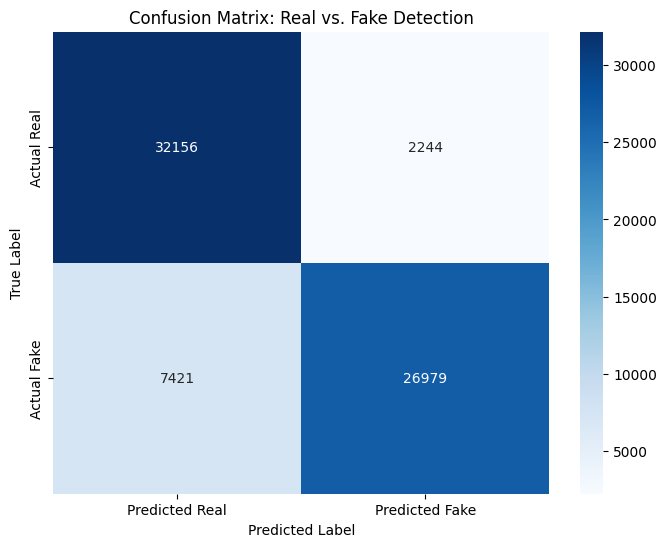

In [37]:
# 1. Accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"\n{'='*30}")
print(f"TEST ACCURACY: {acc*100:.2f}%")
print(f"{'='*30}\n")

# 2. Classification Report
print("--- Classification Report ---")
# Target Names: 0=Real, 1=Fake
print(classification_report(all_labels, all_preds, target_names=['Real (Original)', 'Fake (Manipulated)']))

# 3. Confusion Matrix Visualization
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Real', 'Predicted Fake'],
            yticklabels=['Actual Real', 'Actual Fake'])
plt.title('Confusion Matrix: Real vs. Fake Detection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

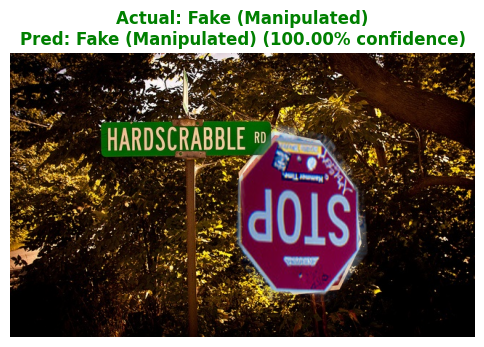

File Path: /kaggle/input/defactosplicing/splicing_6_img/img/11740_000000487551.tif
Raw Probability Score (0=Real, 1=Fake): 1.0000


In [38]:
import random
import matplotlib.pyplot as plt
import torch
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

# ==========================================
# --- 1. SETUP & HELPER FUNCTION ---
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the exact same transform used in Validation/Testing
inference_transform = A.Compose([
    A.Resize(380, 380),
    # Normalize: (Pixel / 255.0) - No ImageNet mean subtraction
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
    ToTensorV2()
])

def predict_single_image(image_path, actual_label_name):
    """
    Reads an image, prepares it for the model, and prints the result.
    """
    # 1. Read and Process Image
    original_img = cv2.imread(image_path)
    if original_img is None:
        print(f"Error: Could not read image at {image_path}")
        return

    # Convert to RGB for display and inference
    image_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    # Apply Augmentations (Resize + Normalize + Tensor)
    transformed = inference_transform(image=image_rgb)
    input_tensor = transformed['image'].unsqueeze(0) # Add batch dimension: [1, 3, 380, 380]
    input_tensor = input_tensor.to(device)
    
    # 2. Inference
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probability = torch.sigmoid(logits).item()
        
    # 3. Interpret Result
    # Threshold is 0.5
    prediction_label = "Fake (Manipulated)" if probability > 0.5 else "Real (Original)"
    confidence = probability if probability > 0.5 else 1 - probability
    
    # Color code for title (Green if correct, Red if wrong)
    is_correct = (probability > 0.5 and "Fake" in actual_label_name) or (probability <= 0.5 and "Real" in actual_label_name)
    title_color = 'green' if is_correct else 'red'

    # 4. Display
    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb)
    plt.axis('off')
    
    plt.title(f"Actual: {actual_label_name}\nPred: {prediction_label} ({confidence*100:.2f}% confidence)", 
              color=title_color, fontweight='bold', fontsize=12)
    plt.show()

    # Text Output
    print(f"{'='*30}")
    print(f"File Path: {image_path}")
    print(f"Raw Probability Score (0=Real, 1=Fake): {probability:.4f}")
    print(f"{'='*30}")

# ==========================================
# --- 2. SELECT A RANDOM IMAGE ---
# ==========================================

# Flatten the test_data dictionary into a list so we can pick randomly
# Structure of test_data: {'splicing': [(fake_path, real_path), ...]}
all_test_files = []

if 'test_data' in locals():
    for ds_type, pairs in test_data.items():
        for fake_p, real_p in pairs:
            all_test_files.append((fake_p, "Fake (Manipulated)"))
            all_test_files.append((real_p, "Real (Original)"))
            
    if len(all_test_files) > 0:
        # Pick one random image tuple
        random_path, random_label = random.choice(all_test_files)
        
        # Run Prediction
        predict_single_image(random_path, random_label)
    else:
        print("Test data list is empty.")
else:
    print("Error: 'test_data' dictionary not found. Please run the splitting script first.")